# Lab Assignment 5
- Name: Sanjushree Rajan
- Reg. no.: BL.EN.U4AIE23130
- Subject: Speech Processing

## Objectives
1. To understand how to construct a triangular filter
2. To learn how multiple triangular filters form a filter bank
3. To design and visualize a Mel Filter Bank
4. To understand the need for FFT bin mapping

In [15]:
import numpy as np
import matplotlib.pyplot as plt

## Objective 1: Construction of Triangular Filters

In [16]:
def triangular_filter(k, a, b, c):
    H = np.zeros_like(k, dtype=float)
    # Rising edge: a <= k <= b
    rising = (k >= a) & (k <= b)
    H[rising] = (k[rising] - a) / (b - a)
    # Falling edge: b <= k <= c
    falling = (k >= b) & (k <= c)
    H[falling] = (c - k[falling]) / (c - b)
    return H

### Task 1(i): Single Triangular Filter — points = (10, 20, 30)

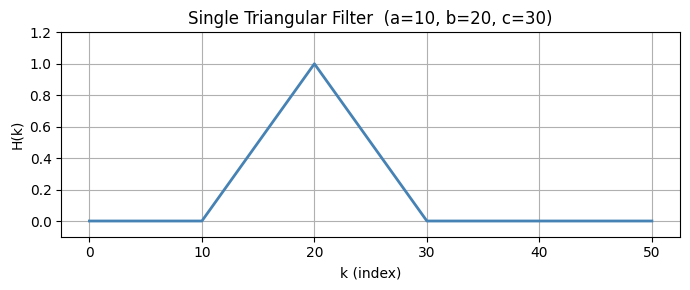

In [17]:
k = np.arange(0, 51)  # index range
a, b, c = 10, 20, 30
H = triangular_filter(k, a, b, c)

plt.figure(figsize=(7, 3))
plt.plot(k, H, color='steelblue', linewidth=2)
plt.title(f'Single Triangular Filter  (a={a}, b={b}, c={c})')
plt.xlabel('k (index)')
plt.ylabel('H(k)')
plt.ylim(-0.1, 1.2)
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 1(ii): Multiple Triangular Filters — points = [(10,20,30), (20,30,40), (30,40,50)]

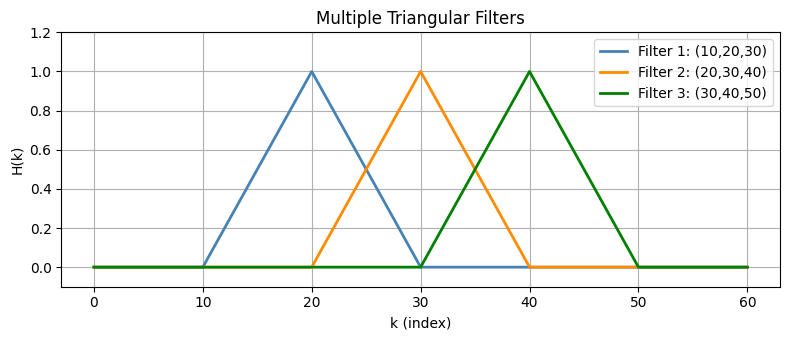

In [18]:
k = np.arange(0, 61)
filter_points = [(10, 20, 30), (20, 30, 40), (30, 40, 50)]
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 3.5))
for i, (a, b, c) in enumerate(filter_points):
    H = triangular_filter(k, a, b, c)
    plt.plot(k, H, color=colors[i], linewidth=2, label=f'Filter {i+1}: ({a},{b},{c})')

plt.title('Multiple Triangular Filters')
plt.xlabel('k (index)')
plt.ylabel('H(k)')
plt.ylim(-0.1, 1.2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 1(iii): Shape Changes — Wider and Narrower Triangles

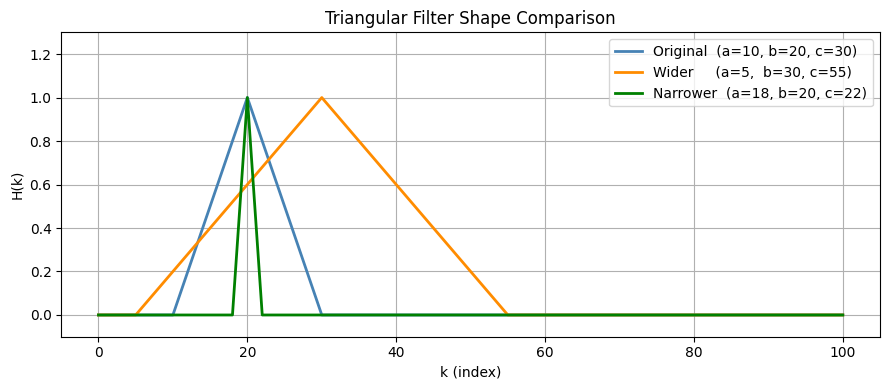

In [19]:
k = np.arange(0, 101)

# Original
H_orig  = triangular_filter(k, 10, 20, 30)   # width = 20
# Wider
H_wide  = triangular_filter(k, 5,  30, 55)   # width = 50
# Narrower
H_narrow = triangular_filter(k, 18, 20, 22)  # width = 4

plt.figure(figsize=(9, 4))
plt.plot(k, H_orig,   color='steelblue',   linewidth=2, label='Original  (a=10, b=20, c=30)')
plt.plot(k, H_wide,   color='darkorange',  linewidth=2, label='Wider     (a=5,  b=30, c=55)')
plt.plot(k, H_narrow, color='green',       linewidth=2, label='Narrower  (a=18, b=20, c=22)')

plt.title('Triangular Filter Shape Comparison')
plt.xlabel('k (index)')
plt.ylabel('H(k)')
plt.ylim(-0.1, 1.3)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Objective 2: Design of Mel Filter Bank

### Step 1: Define Parameters

In [20]:
fs   = 16000   # Sampling frequency (Hz)
N    = 512     # FFT size
M    = 20      # Number of Mel filters
fmin = 0       # Minimum frequency (Hz)
fmax = fs / 2  # Maximum frequency = Nyquist = 8000 Hz

print(f'Sampling frequency : {fs} Hz')
print(f'FFT size           : {N}')
print(f'Number of filters  : {M}')
print(f'fmin               : {fmin} Hz')
print(f'fmax               : {fmax} Hz')

Sampling frequency : 16000 Hz
FFT size           : 512
Number of filters  : 20
fmin               : 0 Hz
fmax               : 8000.0 Hz


### Step 2: Convert Frequency Limits to Mel Scale

In [21]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)

mel_min = hz_to_mel(fmin)
mel_max = hz_to_mel(fmax)

print(f'MEL(fmin) = {mel_min:.2f}')
print(f'MEL(fmax) = {mel_max:.2f}')

MEL(fmin) = 0.00
MEL(fmax) = 2840.02


### Step 3: Generate Equally Spaced Mel Points (ΔMel)

In [22]:
# M+2 points: M filters need M+2 boundary points
mel_points = np.linspace(mel_min, mel_max, M + 2)

print('Mel points (equally spaced):')
print(np.round(mel_points, 2))

Mel points (equally spaced):
[   0.    135.24  270.48  405.72  540.96  676.2   811.44  946.67 1081.91
 1217.15 1352.39 1487.63 1622.87 1758.11 1893.35 2028.59 2163.83 2299.07
 2434.31 2569.54 2704.78 2840.02]


### Step 4 & 5: Convert Mel Points -> Frequencies -> FFT Bins

In [23]:
# Convert Mel → Hz
freq_points = mel_to_hz(mel_points)

# Convert Hz → FFT bin index
bin_points = np.floor((N + 1) * freq_points / fs).astype(int)

print(f"{'Filter':>8} {'Mel':>10} {'Freq (Hz)':>12} {'FFT Bin':>10}")
print('-' * 46)
for i, (m, f, b) in enumerate(zip(mel_points, freq_points, bin_points)):
    print(f"{i:>8} {m:>10.2f} {f:>12.2f} {b:>10}")

  Filter        Mel    Freq (Hz)    FFT Bin
----------------------------------------------
       0       0.00         0.00          0
       1     135.24        89.25          2
       2     270.48       189.87          6
       3     405.72       303.33          9
       4     540.96       431.25         13
       5     676.20       575.48         18
       6     811.44       738.10         23
       7     946.67       921.46         29
       8    1081.91      1128.19         36
       9    1217.15      1361.27         43
      10    1352.39      1624.08         52
      11    1487.63      1920.39         61
      12    1622.87      2254.48         72
      13    1758.11      2631.17         84
      14    1893.35      3055.88         97
      15    2028.59      3534.75        113
      16    2163.83      4074.66        130
      17    2299.07      4683.42        150
      18    2434.31      5369.79        172
      19    2569.54      6143.66        196
      20    2704.78      7016

# Reports

### Report (i): FFT Bin vs Frequency Plot

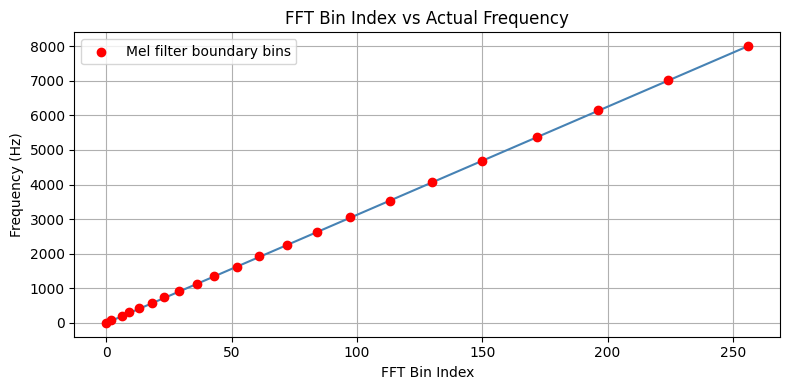

In [24]:
all_bins  = np.arange(0, N // 2 + 1)
all_freqs = all_bins * fs / N

plt.figure(figsize=(8, 4))
plt.plot(all_bins, all_freqs, color='steelblue', linewidth=1.5)
plt.scatter(bin_points, freq_points, color='red', zorder=5,
            label='Mel filter boundary bins')
plt.title('FFT Bin Index vs Actual Frequency')
plt.xlabel('FFT Bin Index')
plt.ylabel('Frequency (Hz)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Report (ii): Mel Points Plot

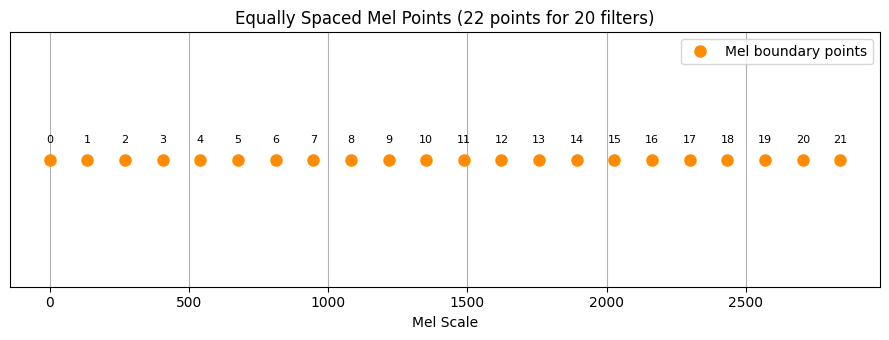

In [25]:
plt.figure(figsize=(9, 3.5))
plt.plot(mel_points, np.zeros_like(mel_points), 'o', color='darkorange',
         markersize=8, label='Mel boundary points')
for i, m in enumerate(mel_points):
    plt.annotate(f'{i}', (m, 0), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=8)

plt.title(f'Equally Spaced Mel Points ({M+2} points for {M} filters)')
plt.xlabel('Mel Scale')
plt.yticks([])
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

### Report (iii): Print Triangular Filter Points (a, b, c) for All Filters

In [26]:
print(f"{'Filter m':>10} {'a = b(m-1)':>12} {'b = b(m)':>12} {'c = b(m+1)':>12}")
print('-' * 50)
for m in range(1, M + 1):
    a = bin_points[m - 1]
    b = bin_points[m]
    c = bin_points[m + 1]
    print(f"{m:>10} {a:>12} {b:>12} {c:>12}")

  Filter m   a = b(m-1)     b = b(m)   c = b(m+1)
--------------------------------------------------
         1            0            2            6
         2            2            6            9
         3            6            9           13
         4            9           13           18
         5           13           18           23
         6           18           23           29
         7           23           29           36
         8           29           36           43
         9           36           43           52
        10           43           52           61
        11           52           61           72
        12           61           72           84
        13           72           84           97
        14           84           97          113
        15           97          113          130
        16          113          130          150
        17          130          150          172
        18          150          172          196

### Step 6 + Report (iv): Construct and Plot the Mel Filter Bank

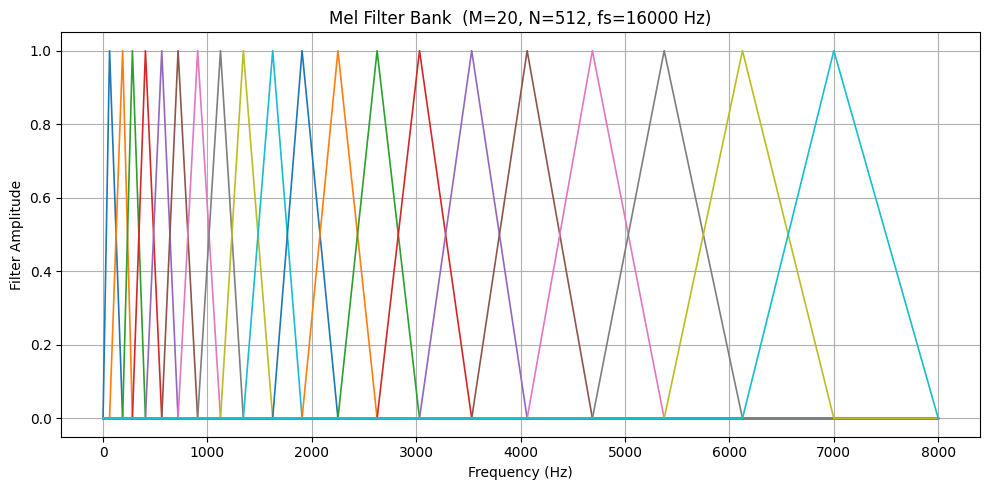

In [27]:
num_bins = N // 2 + 1          # 0 … N/2
k = np.arange(num_bins)

filter_bank = np.zeros((M, num_bins))

for m in range(1, M + 1):
    b_prev = bin_points[m - 1]   # a
    b_curr = bin_points[m]       # b (peak)
    b_next = bin_points[m + 1]   # c

    for ki in k:
        if b_prev <= ki <= b_curr and b_curr != b_prev:
            filter_bank[m - 1, ki] = (ki - b_prev) / (b_curr - b_prev)
        elif b_curr <= ki <= b_next and b_next != b_curr:
            filter_bank[m - 1, ki] = (b_next - ki) / (b_next - b_curr)

plt.figure(figsize=(10, 5))
for m in range(M):
    plt.plot(k * fs / N, filter_bank[m], linewidth=1.2)

plt.title(f'Mel Filter Bank  (M={M}, N={N}, fs={fs} Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Filter Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

### Report (v): Change Parameters and Visualize

Try different values of `M`, `N`, `fs`, `fmin`, `fmax` below and re-run.

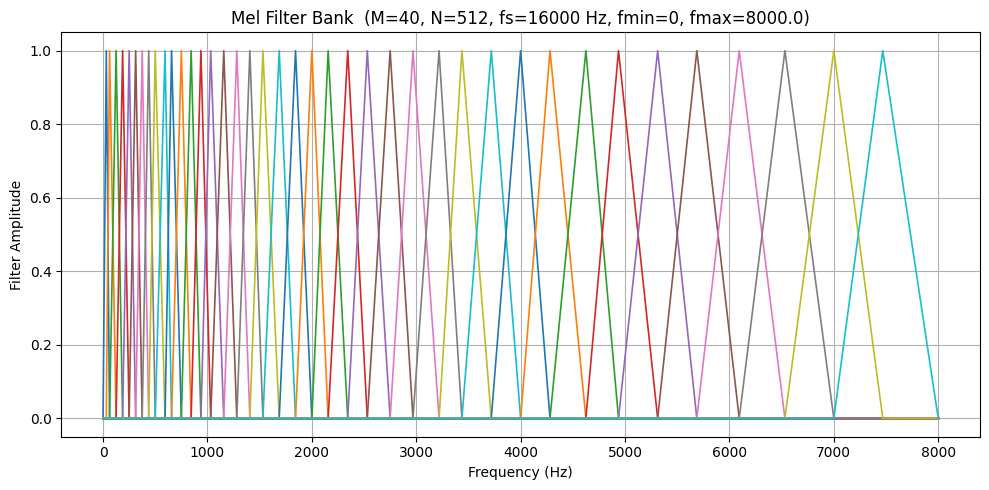

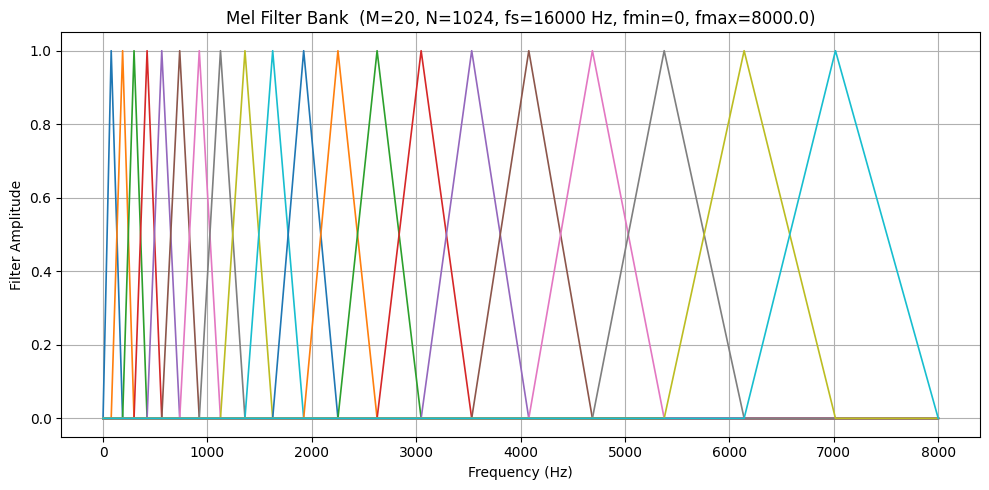

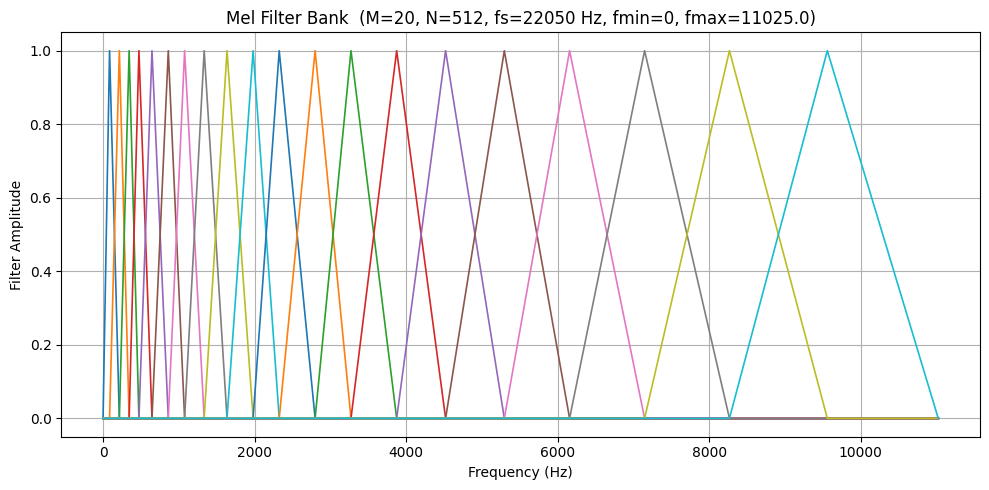

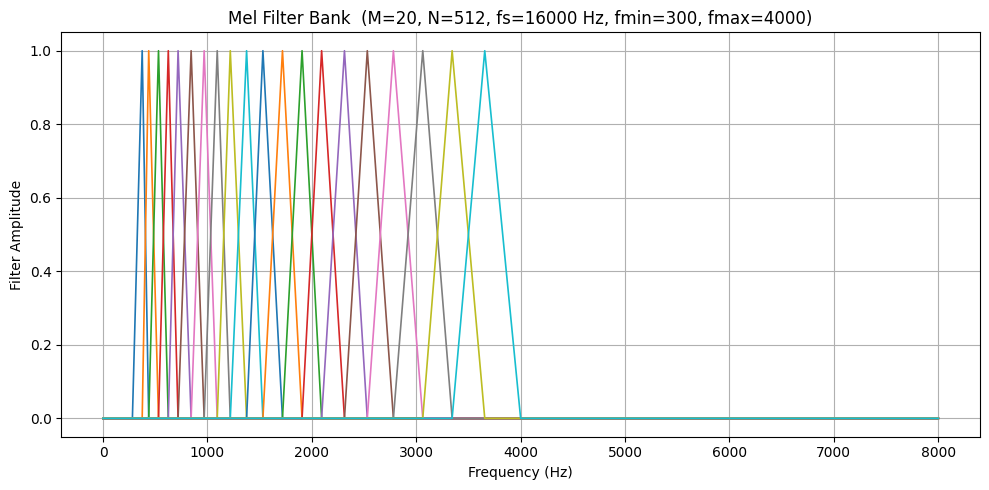

In [28]:
def plot_mel_filter_bank(fs=16000, N=512, M=20, fmin=0, fmax=None):
    if fmax is None:
        fmax = fs / 2

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)
    mel_pts  = np.linspace(mel_min, mel_max, M + 2)
    freq_pts = mel_to_hz(mel_pts)
    bin_pts  = np.floor((N + 1) * freq_pts / fs).astype(int)

    num_bins = N // 2 + 1
    k = np.arange(num_bins)
    fb = np.zeros((M, num_bins))

    for m in range(1, M + 1):
        bp, bc, bn = bin_pts[m-1], bin_pts[m], bin_pts[m+1]
        for ki in k:
            if bp <= ki <= bc and bc != bp:
                fb[m-1, ki] = (ki - bp) / (bc - bp)
            elif bc <= ki <= bn and bn != bc:
                fb[m-1, ki] = (bn - ki) / (bn - bc)

    plt.figure(figsize=(10, 5))
    for m in range(M):
        plt.plot(k * fs / N, fb[m], linewidth=1.2)
    plt.title(f'Mel Filter Bank  (M={M}, N={N}, fs={fs} Hz, fmin={fmin}, fmax={fmax})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Filter Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Experiment with different parameters

# More filters
plot_mel_filter_bank(fs=16000, N=512,  M=40)

# Larger FFT
plot_mel_filter_bank(fs=16000, N=1024, M=20)

# Higher sampling rate
plot_mel_filter_bank(fs=22050, N=512,  M=20)

# Restricted frequency range
plot_mel_filter_bank(fs=16000, N=512,  M=20, fmin=300, fmax=4000)